<a href="https://colab.research.google.com/github/Prateeksha1507/Technical-Assessment-Predictive-Modeling-for-Feature-shipment-prediction/blob/main/assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [175]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

import warnings
warnings.filterwarnings("ignore")

## **Dataset Loading**

In [176]:
from google.colab import files

uploaded = files.upload()

Saving Software_feature_shipment_data_set.csv to Software_feature_shipment_data_set (3).csv


In [177]:
df = pd.read_csv("Software_feature_shipment_data_set.csv")

In [178]:
df.head()

,planned_shipment_date,team_size,feature_complexity,num_dependencies,sprint_length_weeks,num_blockers,holidays_in_sprint,priority_encoded,past_avg_delay_days,estimated_bug_count,delay_days
0,2021-01-17,9,8.168887,3,2,0,0,0,-0.965238,2,15
1,2021-01-24,23,6.557334,1,2,0,0,0,0.444158,6,11
2,2021-02-07,16,8.275576,1,3,0,0,1,1.645090,8,15
3,2021-02-07,18,3.938867,8,2,0,0,0,-3.751354,1,11
4,2021-02-14,21,7.361716,2,2,0,1,1,-0.958348,6,16


In [179]:
df.shape

(1300, 11)

In [180]:
df.columns

Index(['planned_shipment_date', 'team_size', 'feature_complexity',
       'num_dependencies', 'sprint_length_weeks', 'num_blockers',
       'holidays_in_sprint', 'priority_encoded', 'past_avg_delay_days',
       'estimated_bug_count', 'delay_days'],
      dtype='object')

In [181]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   planned_shipment_date  1300 non-null   object 
 1   team_size              1300 non-null   int64  
 2   feature_complexity     1300 non-null   float64
 3   num_dependencies       1300 non-null   int64  
 4   sprint_length_weeks    1300 non-null   int64  
 5   num_blockers           1300 non-null   int64  
 6   holidays_in_sprint     1300 non-null   int64  
 7   priority_encoded       1300 non-null   int64  
 8   past_avg_delay_days    1300 non-null   float64
 9   estimated_bug_count    1300 non-null   int64  
 10  delay_days             1300 non-null   int64  
dtypes: float64(2), int64(8), object(1)
memory usage: 111.8+ KB


In [182]:
df.describe()

,team_size,feature_complexity,num_dependencies,sprint_length_weeks,num_blockers,holidays_in_sprint,priority_encoded,past_avg_delay_days,estimated_bug_count,delay_days
count,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000
mean,13.682308,5.460658,2.995385,2.500769,0.376923,0.160769,1.129231,0.037082,5.051538,13.428462
std,6.386800,2.612645,1.735375,0.684705,0.650284,0.367459,0.682053,1.977190,2.177912,4.874274
min,3.000000,1.008365,0.000000,2.000000,0.000000,0.000000,0.000000,-6.508958,0.000000,2.000000
25%,8.000000,3.196076,2.000000,2.000000,0.000000,0.000000,1.000000,-1.324640,4.000000,10.000000
50%,14.000000,5.551511,3.000000,2.000000,0.000000,0.000000,1.000000,0.075471,5.000000,13.000000
75%,19.000000,7.721968,4.000000,3.000000,1.000000,0.000000,2.000000,1.409820,6.000000,17.000000
max,24.000000,9.999109,9.000000,4.000000,2.000000,1.000000,2.000000,6.991756,13.000000,29.000000


# **No null value found.**

In [183]:
df.isnull().sum()

,0
planned_shipment_date,0
team_size,0
feature_complexity,0
num_dependencies,0
sprint_length_weeks,0
num_blockers,0
holidays_in_sprint,0
priority_encoded,0
past_avg_delay_days,0
estimated_bug_count,0


# **No Duplicate values encountered.**

In [184]:
df.duplicated().sum()

np.int64(0)

In [185]:
df["planned_shipment_date"] = pd.to_datetime(df["planned_shipment_date"])

In [186]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   planned_shipment_date  1300 non-null   datetime64[ns]
 1   team_size              1300 non-null   int64         
 2   feature_complexity     1300 non-null   float64       
 3   num_dependencies       1300 non-null   int64         
 4   sprint_length_weeks    1300 non-null   int64         
 5   num_blockers           1300 non-null   int64         
 6   holidays_in_sprint     1300 non-null   int64         
 7   priority_encoded       1300 non-null   int64         
 8   past_avg_delay_days    1300 non-null   float64       
 9   estimated_bug_count    1300 non-null   int64         
 10  delay_days             1300 non-null   int64         
dtypes: datetime64[ns](1), float64(2), int64(8)
memory usage: 111.8 KB


# **Feature Engineering**
5 additional features extracted.


In [187]:
df["year"] = df["planned_shipment_date"].dt.year
df["month"] = df["planned_shipment_date"].dt.month
df["day"] = df["planned_shipment_date"].dt.day
df["quarter"] = df["planned_shipment_date"].dt.quarter
df["week"] = df["planned_shipment_date"].dt.isocalendar().week.astype(int)

In [188]:
df.head()

,planned_shipment_date,team_size,feature_complexity,num_dependencies,sprint_length_weeks,num_blockers,holidays_in_sprint,priority_encoded,past_avg_delay_days,estimated_bug_count,delay_days,year,month,day,quarter,week
0,2021-01-17,9,8.168887,3,2,0,0,0,-0.965238,2,15,2021,1,17,1,2
1,2021-01-24,23,6.557334,1,2,0,0,0,0.444158,6,11,2021,1,24,1,3
2,2021-02-07,16,8.275576,1,3,0,0,1,1.645090,8,15,2021,2,7,1,5
3,2021-02-07,18,3.938867,8,2,0,0,0,-3.751354,1,11,2021,2,7,1,5
4,2021-02-14,21,7.361716,2,2,0,1,1,-0.958348,6,16,2021,2,14,1,6


In [189]:
df["days_since_start"] = (
    df["planned_shipment_date"]
    - df["planned_shipment_date"].min()
).dt.days
df.drop(columns=["planned_shipment_date"], inplace=True)

# **Exploratory Data Analysis**

- The distribution of shipment delays appears approximately normal with slight variation. No extreme skewness was observed, making it suitable for regression modeling.

- The dataset is clean with no missing or duplicate values.
- Temporal information was extracted from the shipment date to improve model learning.

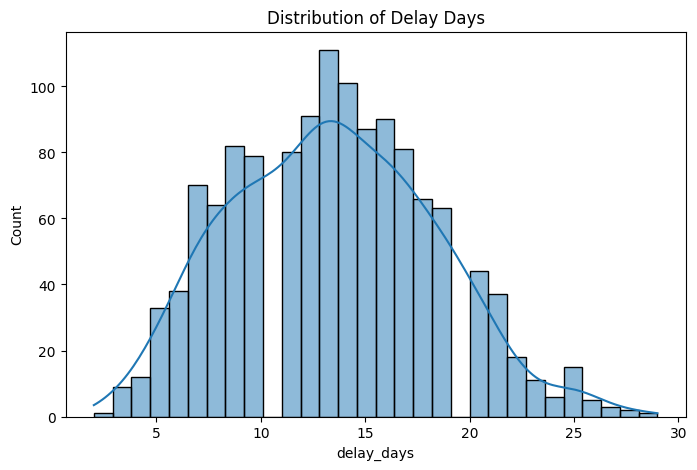

In [190]:
plt.figure(figsize=(8,5))
sns.histplot(df["delay_days"], bins=30, kde=True)
plt.title("Distribution of Delay Days")
plt.show()

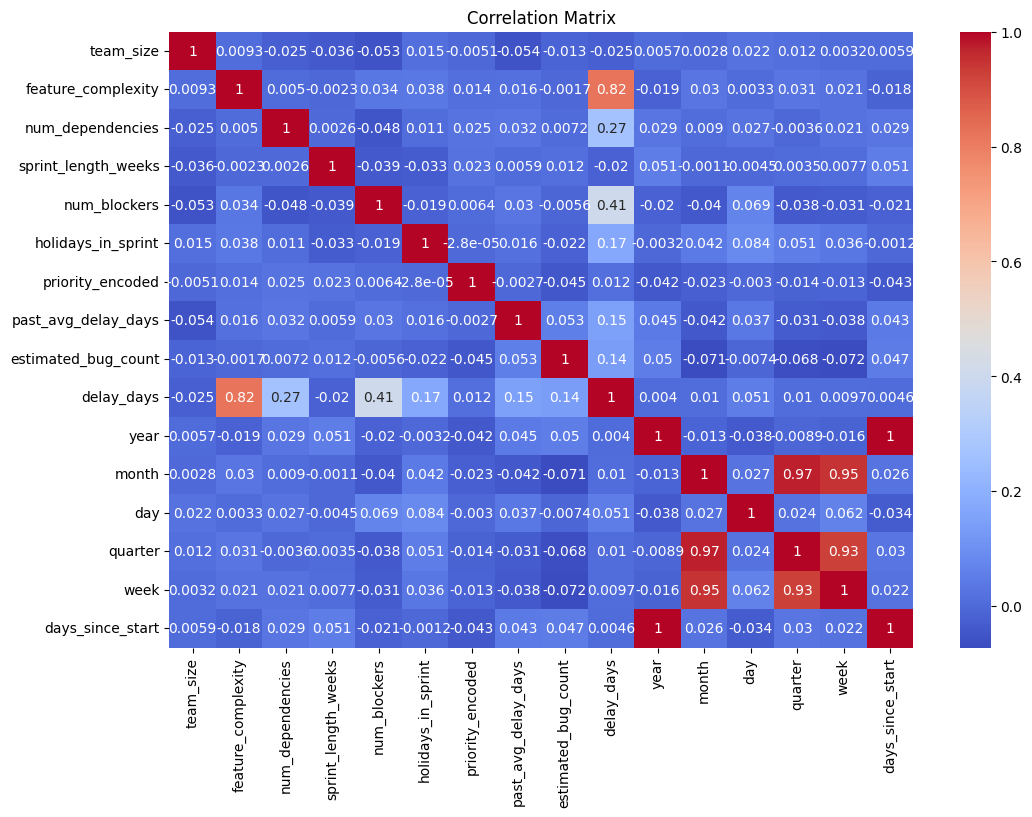

In [191]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

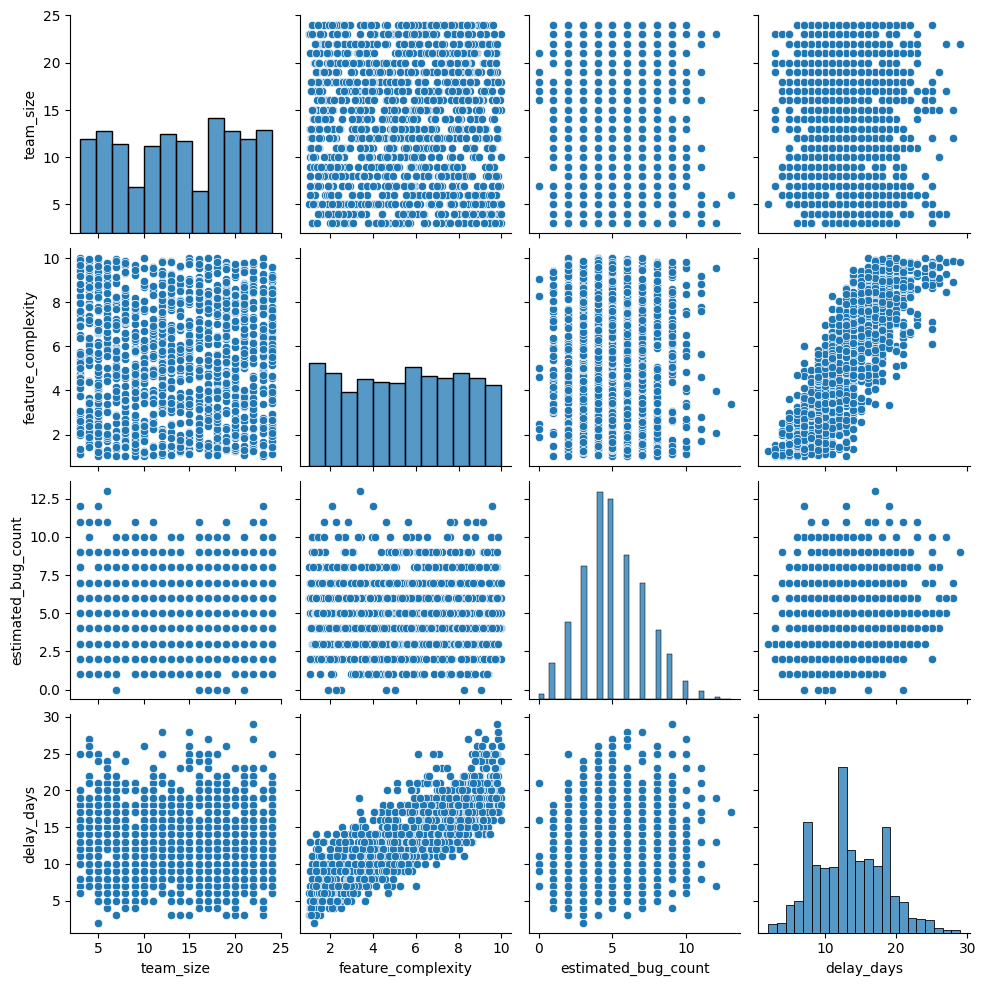

In [192]:
sns.pairplot(df[['team_size',
                 'feature_complexity',
                 'estimated_bug_count',
                 'delay_days']])
plt.show()

In [193]:
X = df.drop("delay_days", axis=1)

y = df["delay_days"]

In [194]:
# Sort data by year, month and day
df = df.sort_values(by=["year", "month", "day"]).reset_index(drop=True)

In [195]:
X = df.drop("delay_days", axis=1)
y = df["delay_days"]

In [196]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [197]:
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (1040, 15)
Testing samples: (260, 15)


# **Linear Regression**

In [198]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

In [199]:
y_pred_lr = lr.predict(X_test)

In [200]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [201]:
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-------------------------")
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("R²  :", round(r2,2))

Linear Regression Results
-------------------------
MAE : 0.88
RMSE: 1.09
R²  : 0.96


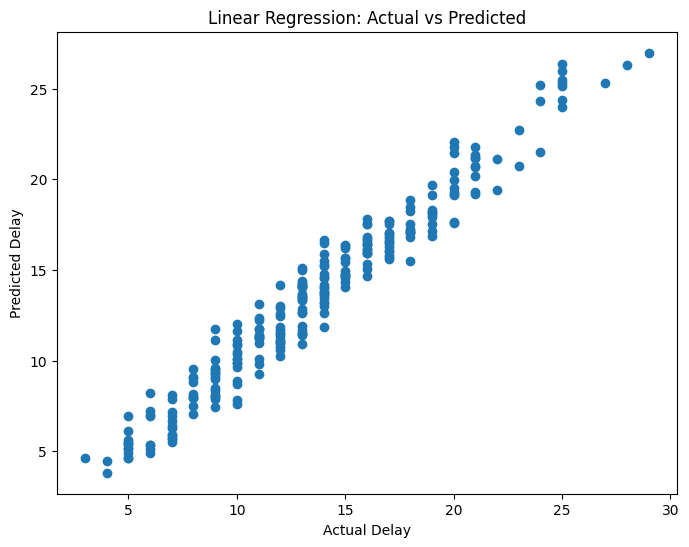

In [202]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual Delay")
plt.ylabel("Predicted Delay")
plt.title("Linear Regression: Actual vs Predicted")

plt.show()

# **Random Forest**

In [203]:
rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

In [204]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("---------------------")
print("MAE :", round(mae_rf,2))
print("RMSE:", round(rmse_rf,2))
print("R²  :", round(r2_rf,2))

Random Forest Results
---------------------
MAE : 1.23
RMSE: 1.59
R²  : 0.91


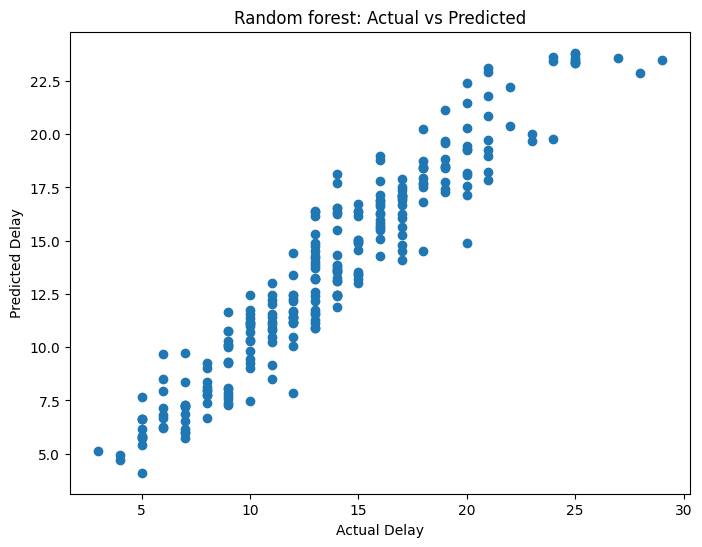

In [205]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Delay")
plt.ylabel("Predicted Delay")
plt.title("Random forest: Actual vs Predicted")

plt.show()

In [206]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,feature_complexity,0.696272
4,num_blockers,0.132358
2,num_dependencies,0.069570
7,past_avg_delay_days,0.026388
8,estimated_bug_count,0.014793
5,holidays_in_sprint,0.011450
0,team_size,0.009396
14,days_since_start,0.008400
11,day,0.008220
13,week,0.008079


In [207]:
from xgboost import XGBRegressor

In [208]:
xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    objective='reg:squarederror'
)

xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

In [209]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost Results")
print("----------------")
print("MAE :", round(mae_xgb, 3))
print("RMSE:", round(rmse_xgb, 3))
print("R²  :", round(r2_xgb, 3))

XGBoost Results
----------------
MAE : 1.003
RMSE: 1.286
R²  : 0.939


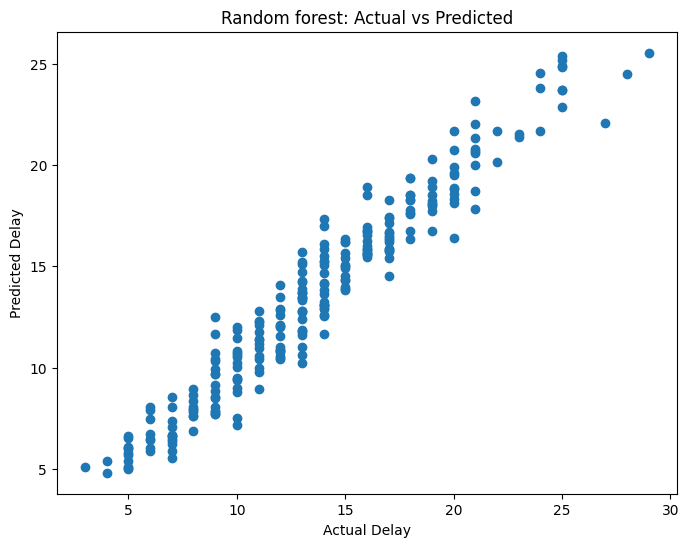

In [210]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_xgb)

plt.xlabel("Actual Delay")
plt.ylabel("Predicted Delay")
plt.title("Random forest: Actual vs Predicted")

plt.show()

In [213]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE": [
        mae,
        mae_rf,
        mae_xgb
    ],
    "RMSE": [
        rmse,
        rmse_rf,
        rmse_xgb
    ],
    "R2 Score": [
        r2,
        r2_rf,
        r2_xgb
    ]
})

results = results.round(3)

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.880,1.086,0.957
1,Random Forest,1.234,1.593,0.907
2,XGBoost,1.003,1.286,0.939


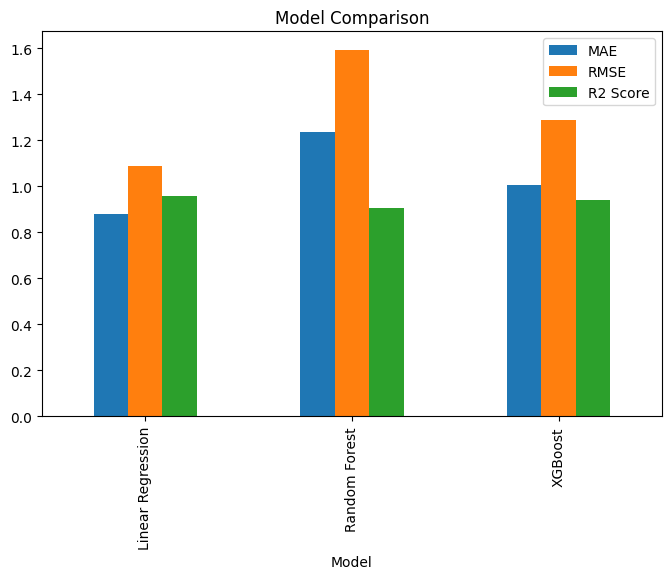

In [214]:
results.plot(
    x="Model",
    y=["MAE", "RMSE","R2 Score"],
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Comparison")
plt.show()

- Three regression models were evaluated:
  - Linear Regression
  - Random Forest
  - XGBoost

- Linear Regression achieved the lowest MAE and highest R² score on this dataset.

- This suggests that the relationship between the engineered features and shipment delay is predominantly linear.

- Increasing model complexity through Random Forest and XGBoost did not improve predictive performance, hence, simpler model outperformed more complex models since the underlying data is linear.
